<a href="https://colab.research.google.com/github/galahad20/assignment_Data_Quality_Report/blob/main/ASSIGNMENT_TEMP_DE14_DAY12_DIMAS_ABIAN_IHSAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Data Quality Report
by `Dimas Abian Ihsan`

**Dibimbing - Batch 14 | DE**

**Riwayat Implementasi Github Collaboration Flow
 :** https://github.com/galahad20/assignment_Data_Quality_Report

Objectives
- Student mampu menghasilkan dataset simulasi menggunakan Python (pandas, random, datetime).
- Student mampu melakukan data profiling untuk mengidentifikasi missing value, duplikasi, dan nilai invalid.
- Student mampu melakukan data cleaning untuk menghapus duplikasi, menormalisasi kategori, dan mengisi data kosong sesuai aturan.
- Student mampu melakukan data validation dengan mendefinisikan dan menerapkan aturan validasi schema menggunakan Pandera, pandasql, atau Great Expectations.
- Student mampu menyajikan hasil analisis dalam bentuk tabel ringkasan, visualisasi, dan insight singkat.


##Persiapan

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Parameter
n_rows = 200  # jumlah baris data
start_date = datetime(2023, 5, 1)
categories = ["Elektronik", "Electronics", "elektronik", "Fashion", "Fesyen"]
statuses = ["paid", "pending", "cancelled"]
emails = ["@mail.com", "@gmail.com", "@yahoo.com", ""]

data = []
for i in range(5001, 5001 + n_rows):
    cust_id = f"C{str(random.randint(1, 50)).zfill(3)}"
    prod_id = f"P{str(random.randint(1, 30)).zfill(3)}" if random.random() > 0.05 else ""  # 5% missing

    # tanggal (ada invalid & salah format)
    if random.random() < 0.05:
        tanggal = "2023-02-31"
    elif random.random() < 0.05:
        tanggal = (start_date + timedelta(days=random.randint(0, 30))).strftime("%d/%m/%Y")
    else:
        tanggal = (start_date + timedelta(days=random.randint(0, 30))).strftime("%Y-%m-%d")

    jumlah = random.choice([random.randint(1, 5), -1, 0]) if random.random() < 0.1 else random.randint(1, 5)
    harga = random.choice([0, 99999999, random.randint(100, 1_000_000)]) if random.random() < 0.1 else random.randint(100, 1_000_000)

    if random.random() < 0.1:
        email = f"user{i}mail.com"
    elif random.random() < 0.05:
        email = ""
    else:
        email = f"user{i}{random.choice(emails)}"

    kode_pos = str(random.randint(10000, 99999)) if random.random() > 0.1 else random.choice(["4012a", ""])
    status = random.choice(statuses)
    kategori = random.choice(categories)

    data.append([i, cust_id, prod_id, tanggal, jumlah, harga, email, kode_pos, status, kategori])

# Buat DataFrame
df = pd.DataFrame(data, columns=["order_id","customer_id","product_id","tanggal","jumlah","harga","email","kode_pos","status","kategori"])

# Tambahkan duplikat
duplicates = df.sample(5)
df = pd.concat([df, duplicates], ignore_index=True)

# Simpan CSV
df.to_csv("assessment_orders_large.csv", index=False)
print("✅ Dataset berhasil dibuat: assessment_orders_large.csv")



✅ Dataset berhasil dibuat: assessment_orders_large.csv


Setelah melakukan generate dataset, lakukan langkah-langkah berikut:






##Data Profiling
Instruksi:
- Hitung jumlah record total.
- Hitung jumlah missing value (per kolom).
- Hitung jumlah duplicate order_id.


Deteksi nilai invalid yang meliputi:
- jumlah ≤ 0
- harga ≤ 0 atau > 10.000.000
- tanggal salah format atau tidak valid
- email tanpa @

Buat distribusi sederhana untuk jumlah dan harga (bisa histogram, boxplot, atau statistik deskriptif).


Output yang diharapkan:
- Buatlah tabel ringkasan profil data otomatis menggunakan kode python.
- Buatlah visualisasi distribusi menggunakan salah satu jenis (histogram, boxplot, atau statistik deskriptif).
- Buat insight singkat mengenai hasil profiling data.
- Contoh:
 “10% transaksi bermasalah, mayoritas error di harga dan tanggal”.

###Tipe data, 5 data pertama

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   order_id     205 non-null    int64 
 1   customer_id  205 non-null    object
 2   product_id   205 non-null    object
 3   tanggal      205 non-null    object
 4   jumlah       205 non-null    int64 
 5   harga        205 non-null    int64 
 6   email        205 non-null    object
 7   kode_pos     205 non-null    object
 8   status       205 non-null    object
 9   kategori     205 non-null    object
dtypes: int64(3), object(7)
memory usage: 16.1+ KB


In [4]:
df.head()

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori
0,5001,C030,,2023-05-23,3,342401,user5001mail.com,4012a,pending,elektronik
1,5002,C012,P014,2023-05-29,5,369424,user5002@mail.com,49316,pending,Elektronik
2,5003,C004,,2023-05-29,1,189798,user5003@mail.com,16201,paid,Fashion
3,5004,C027,P007,2023-05-19,5,695342,user5004mail.com,,pending,Fashion
4,5005,C042,P012,31/05/2023,1,551401,user5005@gmail.com,25029,cancelled,Fashion


### Data Profiling

In [5]:
#function untuk deteksi missing values
def missing_values(df):
    missing = 0
    #hitung null
    null_count = df.isnull().sum()
    #hitung empty string
    empty_string_count = (df == '').sum()
    #hitung spasi
    space_count = (df == ' ').sum()
    #jumlah missing
    missing = null_count + empty_string_count + space_count

    print(missing[missing > 0] if missing.sum() > 0 else "None")
    return missing

def invalid_order(df):
    #cek jumlah yang invalid ketika bernilai 0 atau di bawah 0
    jumlah_invalid = df[df['jumlah'] <= 0].shape[0]
    #harga invalid
    harga_invalid = df[(df['harga'] <= 0) | (df['harga'] > 10_000_000)].shape[0]
    #tanggal invalid dimulai dengan mengubah tipe data tanggal ke datetime
    tmp_tanggal = pd.to_datetime(df['tanggal'], errors='coerce', format='%Y-%m-%d') #akan mengubah yang tidak valid menjadi NaT
    tanggal_invalid = tmp_tanggal.isnull().sum()
    #email invalid
    email_invalid = (~df['email'].str.contains('@', na=False)).sum()
    print(f"Jumlah yang invalid : {jumlah_invalid} \nHarga yang Invalid  : {harga_invalid} \nTanggal yang Invalid: {tanggal_invalid} \nEmail yang Invalid  : {email_invalid}")
    return jumlah_invalid, harga_invalid, tanggal_invalid, email_invalid


#profiling function
def profile_data(df, name):
    print(f"{'='*50}")
    print(f"PROFILING: {name}")
    print(f"{'='*50}")
    print(f"Records: {len(df)}")
    print(f"Columns: {len(df.columns)}")
    print(f"\nMissing Values:")
    missing_values(df)
    print(f"\nDuplicate order_id (Rows): {df.duplicated(subset=['order_id']).sum()}")
    print(f"{'='*50}")
    print(f"\nInvalid Order: ")
    invalid_order(df)
    print()

profile_data(df, 'assessment_orders_large')

PROFILING: assessment_orders_large
Records: 205
Columns: 10

Missing Values:
product_id    12
email          8
kode_pos      12
dtype: int64

Duplicate order_id (Rows): 5

Invalid Order: 
Jumlah yang invalid : 11 
Harga yang Invalid  : 20 
Tanggal yang Invalid: 24 
Email yang Invalid  : 71



### Visualisasi dengan boxplot

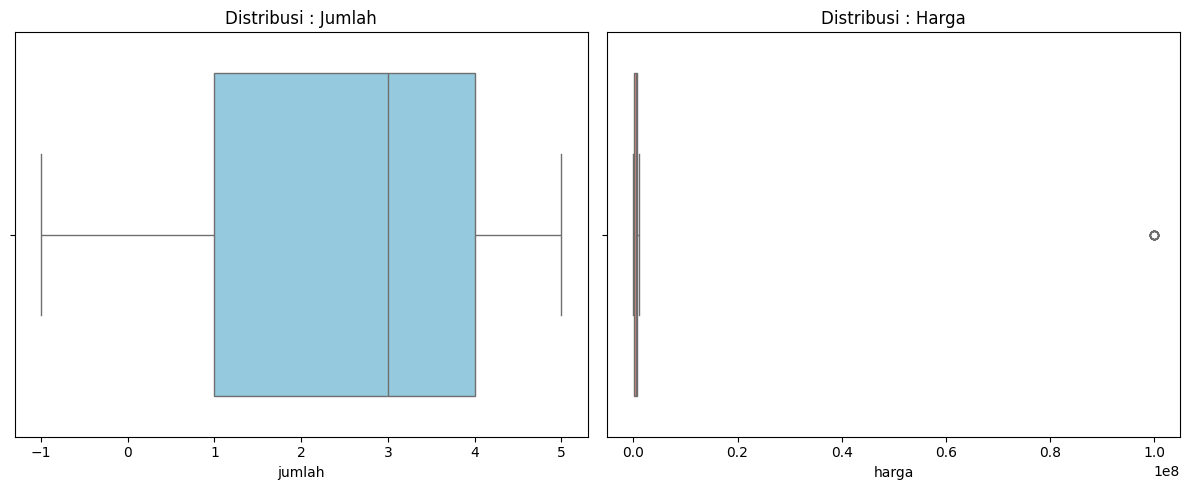

In [6]:
# visualiasi dengna boxplot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot untuk Jumlah
sns.boxplot(x=df['jumlah'], ax=ax[0], color='skyblue')
ax[0].set_title('Distribusi : Jumlah') # Tambahkan judul

# Plot untuk Harga
sns.boxplot(x=df['harga'], ax=ax[1], color='salmon')
ax[1].set_title('Distribusi : Harga') # Tambahkan judul

plt.tight_layout()
plt.show()

Berdasarkan visualisasi boxplot, diketahui bahwa:
- Kolom Jumlah memiliki distribusi yang tidak wajar dimana nilai minimumnya berada di -1. Seharusnya jumlah dari suatu barang yang dipesan tidak boleh kurang dari 1. Sehingga ini menunjukkan adanya data yang tidak normal.

- Distribusi data pada kolom harga memiliki outlier ekstrem yang berbeda jauh dari data lain pada kolom tersebut. Sehingga perlu dilakukan data cleaning pada tahap selanjutnya.

## Data Cleaning

Instruksi:
- Hapus record duplicate berdasarkan order_id.
- Normalisasi kategori produk (Elektronik, Electronics, elektronik → elektronik; Fashion, Fesyen → fashion).
- Isi missing kode_pos dengan default 00000.
- Catat jumlah baris sebelum & sesudah cleaning.


### Kondisi data sebelum cleaning


In [7]:
df.head(10)

,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori
0,5001,C030,,2023-05-23,3,342401,user5001mail.com,4012a,pending,elektronik
1,5002,C012,P014,2023-05-29,5,369424,user5002@mail.com,49316,pending,Elektronik
2,5003,C004,,2023-05-29,1,189798,user5003@mail.com,16201,paid,Fashion
3,5004,C027,P007,2023-05-19,5,695342,user5004mail.com,,pending,Fashion
4,5005,C042,P012,31/05/2023,1,551401,user5005@gmail.com,25029,cancelled,Fashion
5,5006,C048,P002,2023-05-05,1,484278,user5006@yahoo.com,20012,cancelled,Electronics
6,5007,C037,P001,2023-05-27,2,991671,user5007@yahoo.com,22131,cancelled,Elektronik
7,5008,C034,P015,2023-05-05,2,747537,user5008mail.com,93212,pending,elektronik
8,5009,C033,P013,2023-05-02,3,582743,user5009,4012a,cancelled,Elektronik
9,5010,C003,P008,14/05/2023,2,161624,user5010@gmail.com,63875,cancelled,Fesyen


In [8]:
#jumlah baris sebelum proses cleaning
print(f"Jumlah baris sebelum proses cleaning: {len(df)} baris")

Jumlah baris sebelum proses cleaning: 205 baris


In [9]:
df['kategori'].unique()

array(['elektronik', 'Elektronik', 'Fashion', 'Electronics', 'Fesyen'],
      dtype=object)

In [10]:
kp_na = (df['kode_pos'] == '').sum()
kp_null = df['kode_pos'].isnull().sum()
kp_spasi =  (df['kode_pos'] == ' ').sum()

print(f"Kp Na : {kp_na}")
print(f"Kp Null : {kp_null}")
print(f"Kp Spasi : {kp_spasi}")

Kp Na : 12
Kp Null : 0
Kp Spasi : 0


### Proses Cleaning

In [11]:
# Copy untuk cleaning
df_clean = df.copy()

# Hapus duplicate berdasarkan order_id
df_clean = df_clean.drop_duplicates(subset=['order_id'])

# Normalisasi kategori produk
df_clean['kategori'] = df_clean['kategori'].replace(['Elektronik', 'Electronics', 'elektronik'], 'elektronik')
df_clean['kategori'] = df_clean['kategori'].replace(['Fashion', 'Fesyen'], 'fashion')

#isi missing kode pos
df_clean['kode_pos'] = df_clean['kode_pos'].replace(['', ' '], np.nan).fillna('00000')
print("Cleaning completed!")

#jumlah baris sesudah cleaning
print(f"Jumlah baris sesudah proses cleaning: {len(df_clean)} baris")

Cleaning completed!
Jumlah baris sesudah proses cleaning: 200 baris


### Output

In [12]:
#output disimpan dalam orders_clean
df_clean.to_csv("orders_clean.csv", index=False)
print("Dataset berhasil dibuat: orders_clean.csv")

Dataset berhasil dibuat: orders_clean.csv


In [13]:
print("Tampilan 10 Baris Pertama Data Cleaned:")
display(df_clean.head(10))

Tampilan 10 Baris Pertama Data Cleaned:


,order_id,customer_id,product_id,tanggal,jumlah,harga,email,kode_pos,status,kategori
0,5001,C030,,2023-05-23,3,342401,user5001mail.com,4012a,pending,elektronik
1,5002,C012,P014,2023-05-29,5,369424,user5002@mail.com,49316,pending,elektronik
2,5003,C004,,2023-05-29,1,189798,user5003@mail.com,16201,paid,fashion
3,5004,C027,P007,2023-05-19,5,695342,user5004mail.com,00000,pending,fashion
4,5005,C042,P012,31/05/2023,1,551401,user5005@gmail.com,25029,cancelled,fashion
5,5006,C048,P002,2023-05-05,1,484278,user5006@yahoo.com,20012,cancelled,elektronik
6,5007,C037,P001,2023-05-27,2,991671,user5007@yahoo.com,22131,cancelled,elektronik
7,5008,C034,P015,2023-05-05,2,747537,user5008mail.com,93212,pending,elektronik
8,5009,C033,P013,2023-05-02,3,582743,user5009,4012a,cancelled,elektronik
9,5010,C003,P008,14/05/2023,2,161624,user5010@gmail.com,63875,cancelled,fashion


In [14]:
# Perhitungan Statistik
baris_awal = len(df)
baris_akhir = len(df_clean)
duplikat_dihapus = baris_awal - baris_akhir

# Menghitung data missing yang diisi (NaN, empty string, dan spasi)
missing_kp_diisi = (df['kode_pos'].isnull() | (df['kode_pos'] == "") | (df['kode_pos'] == " ")).sum()

#
kategori_unique = df_clean['kategori'].unique()

print("--- RINGKASAN DATA CLEANING ---")
print(f"Jumlah baris data duplicate yang dihapus : {duplikat_dihapus}")
print(f"Jumlah data missing yang diisi (kode_pos): {missing_kp_diisi}")
print(f"Total baris data sebelum cleaning        : {baris_awal}")
print(f"Total baris data sesudah cleaning        : {baris_akhir}")
print(f"Nilai unique pada kategori               : {kategori_unique}")

--- RINGKASAN DATA CLEANING ---
Jumlah baris data duplicate yang dihapus : 5
Jumlah data missing yang diisi (kode_pos): 12
Total baris data sebelum cleaning        : 205
Total baris data sesudah cleaning        : 200
Nilai unique pada kategori               : ['elektronik' 'fashion']


Catatan tambahan:
- Berdasarkan pada hasil data profiling ditemukan missing values tidak hanya pada kode pos, namun product_id, dan email.
- Invalid order juga ditemukan pada jumlah, harga, tanggal, dan email.

## Data validation
**Menggunakan great expectation untuk menerapakan aturan validasi skema untuk dataset yang sudah dibersihkan sebelumnya (df_clean)**

Instruksi:

Definisikan aturan validasi schema:
- order_id: unik, tidak null.
- customer_id & product_id: tidak null.
- jumlah: integer, range 1–100.
- harga: integer, 100–10.000.000.
- email: harus valid format.
- tanggal: harus valid (format YYYY-MM-DD, bukan 31/02/2023).
- status: hanya boleh [paid, pending, cancelled].


###Persiapan

Tahap ini berisi persiapan yang dilakukan berupa instalasi dan import library great expectation

Kemudian dilanjutkan dengan membuat context ephemeral (sementara) untuk menjalankan validasi di Google Colab.

In [15]:
!pip install great_expectations
import great_expectations as gx
context = gx.get_context()

INFO:great_expectations.data_context.types.base:Created temporary directory '/tmp/tmpp_hiymzu' for ephemeral docs site


### Buat Expectation Suite

Membuat wadah aturan yang akan diterapkan pada dataset orders.

In [16]:
# Buat suite
suite = gx.ExpectationSuite(name="orders_suite")
suite = context.suites.add(suite)
print(f"Suite: {suite.name}")

Suite: orders_suite


### Cek kolom yang harus ada - column existence

In [17]:
#kolom yang harus ada
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="order_id"))
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="customer_id"))
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="product_id"))
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="jumlah"))
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="harga"))
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="status"))
suite.add_expectation(gx.expectations.ExpectColumnToExist(column="email"))
print("Column existence expectations added")

Column existence expectations added


### Null values checking

Memvalidasi kolom order_id, customer_id, product_id, dan email tidak null. Disini saya tambahkan email untuk memastikan kembali karena email ini memiliki missing values.

In [18]:
# Tidak boleh null
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="order_id"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="customer_id"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="product_id"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="email"))

print("Null value expectations added")

Null value expectations added


### Uniqueness Checking

Memastikan semua data pada kolom order_id unqiue (tidak ada duplikat)

In [19]:
# Harus unique
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeUnique(column="order_id"))
print("Uniqueness expectation added")

Uniqueness expectation added


### Value Set Validation

Menetapkan value_set untuk kategori pada kolom status hanya boleh berupa paid, pending, dan cancelled.

In [20]:
# Nilai harus dalam set tertentu
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="status",
        value_set=["paid", "pending", "cancelled"]
    )
)
print("Value set expectation added")

Value set expectation added


### Column Values Validation

Digunakan untuk validasi data yang ada pada kolom jumlah berada pada range yang masuk akal tidak berjumlah 0 maupun negatif.

Kemudian validasi harga agar berada pada range 100 - 10.000.000

In [21]:
#jumlah integer range 1-100
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="jumlah", min_value=1, max_value=100))

#harga integer range 100 - 10.000.000
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="harga", min_value=100, max_value=10000000))
print("Column value expectations added")

Column value expectations added


### Format Validation

Section ini untuk validasi format email yang tidak terdapat @ menggunakan regex. Setelah itu deteksi format tanggal yang tidak sesuai dengan format YYYY-MM-DD dan tanggal yang tidak masuk akal seperti YYYY-01-31

In [22]:
# email harus valid format @
suite.add_expectation(gx.expectations.ExpectColumnValuesToMatchRegex(
    column="email",
    regex=r'^[\w\.-]+@[\w\.-]+\.\w+$'
))

suite.add_expectation(
    gx.expectations.ExpectColumnValuesToMatchStrftimeFormat(
        column="tanggal",
        strftime_format="%Y-%m-%d"
    )
)
print("Format expectation added")

Format expectation added


### **Testing all the Suites Validation**

Tahap testing validasi keseluruhan step sebelumnya

In [23]:
# Setup data source dan batch
data_source = context.data_sources.add_pandas("my_pandas")
data_asset = data_source.add_dataframe_asset(name="cleaned_orders")
batch_definition = data_asset.add_batch_definition_whole_dataframe("batch_def")

# Buat batch
batch = batch_definition.get_batch(batch_parameters={"dataframe": df_clean})

# Jalankan validasi
results = batch.validate(suite)

print(f"\nValidation Success: {results.success}")
print(f"Total Expectations: {len(results.results)}")
print(f"Passed: {sum(1 for r in results.results if r.success)}")
print(f"Failed: {sum(1 for r in results.results if not r.success)}")

Calculating Metrics:   0%|          | 0/64 [00:00<?, ?it/s]


Validation Success: False
Total Expectations: 17
Passed: 13
Failed: 4


### **Detailed all the Validation**
- Tampilkan baris yang gagal divalidasi

In [24]:
# Lihat detail per expectation
print(f"           DETAIL VALIDASI\n")
for r in results.results:
    status = "PASS" if r.success else "FAIL"
    exp_type = r.expectation_config.type
    column = r.expectation_config.kwargs.get('column', 'table')
    print(f"\n[{status}] {exp_type} ({column})")

    if not r.success:
        exp_type = r.expectation_config.type
        column = r.expectation_config.kwargs.get('column')
        # Menampilkan jumlah baris yang gagal dan contoh nilainya
        print(f"[{exp_type}] pada kolom '{column}': {r.result['unexpected_count']} baris gagal.")

           DETAIL VALIDASI


[PASS] expect_column_to_exist (order_id)

[PASS] expect_column_values_to_not_be_null (order_id)

[PASS] expect_column_values_to_be_unique (order_id)

[PASS] expect_column_to_exist (customer_id)

[PASS] expect_column_values_to_not_be_null (customer_id)

[PASS] expect_column_to_exist (product_id)

[PASS] expect_column_values_to_not_be_null (product_id)

[PASS] expect_column_to_exist (jumlah)

[FAIL] expect_column_values_to_be_between (jumlah)
[expect_column_values_to_be_between] pada kolom 'jumlah': 11 baris gagal.

[PASS] expect_column_to_exist (harga)

[FAIL] expect_column_values_to_be_between (harga)
[expect_column_values_to_be_between] pada kolom 'harga': 20 baris gagal.

[PASS] expect_column_to_exist (status)

[PASS] expect_column_values_to_be_in_set (status)

[PASS] expect_column_to_exist (email)

[PASS] expect_column_values_to_not_be_null (email)

[FAIL] expect_column_values_to_match_regex (email)
[expect_column_values_to_match_regex] pada kolom 'email

Tampilkan contoh baris yang gagal


In [36]:
#tampilkan baris yang lolos validasi dari keseluruhan data
baris_gagal = max([r.result.get('unexpected_count', 0) for r in results.results])
baris_lolos = len(df_clean) - baris_gagal

print(f"Jumlah baris yang lolos validasi sebesar {baris_lolos} baris dari total {len(df_clean)} baris.\n")

#contoh baris gagal
print(f"{'='*30}")
print("Detail baris yang gagal")
print(f"{'='*30}")
for r in results.results:
    if not r.success:
        exp_type = r.expectation_config.type
        column = r.expectation_config.kwargs.get('column', 'table')
        fail_count = r.result.get('unexpected_count', 0)

        # Mengambil contoh data yang salah (unexpected list)
        samples = r.result.get('partial_unexpected_list', [])

        print(f"\n [{exp_type}] pada kolom '{column}':")
        print(f"Jumlah Baris Gagal : {fail_count} ")
        print(f"Contoh Nilai Salah : {samples}")

Jumlah baris yang lolos validasi sebesar 132 baris dari total 200 baris.

Detail baris yang gagal

 [expect_column_values_to_be_between] pada kolom 'jumlah':
Jumlah Baris Gagal : 11 
Contoh Nilai Salah : [-1, 0, -1, -1, -1, -1, -1, -1, -1, -1, 0]

 [expect_column_values_to_be_between] pada kolom 'harga':
Jumlah Baris Gagal : 20 
Contoh Nilai Salah : [99999999, 99999999, 0, 99999999, 0, 99999999, 0, 99999999, 99999999, 99999999, 0, 0, 0, 0, 0, 99999999, 99999999, 0, 0, 0]

 [expect_column_values_to_match_regex] pada kolom 'email':
Jumlah Baris Gagal : 68 
Contoh Nilai Salah : ['user5001mail.com', 'user5004mail.com', 'user5008mail.com', 'user5009', 'user5012mail.com', 'user5014', 'user5017', 'user5020mail.com', 'user5022', 'user5023', 'user5026mail.com', 'user5029', 'user5035', 'user5037mail.com', 'user5038', 'user5042', 'user5049', 'user5050', 'user5051mail.com', 'user5054mail.com']

 [expect_column_values_to_match_strftime_format] pada kolom 'tanggal':
Jumlah Baris Gagal : 24 
Contoh N